# Dimerisation ODE: fit parameters to an imported CSV

Uses the supplied 17-state dimerisation equations with bounded least-squares fitting in log10 parameter space, following the fitting approach in `v1-9_MTM1_ODE_fitting.ipynb`. The optimiser is `least_squares`, which directly minimises the residual sum of squares.

1. Keep this notebook, `ode_parameters.yaml`, and your experimental CSV in one folder. Install PyYAML with `%pip install pyyaml` if needed.
2. Edit **Fit settings**: select the CSV/time/signal columns, the correct experimental conditions, and the parameter(s) to fit. Only one signal column is fitted per run. Repeat the run for another condition.
3. **Restart Kernel and Run All**. Review convergence, the parameter table, overlay, and residual plot. Exports have a `fit_` prefix and include a separate fitted YAML.

The default fits **Kd_MA only**, holding other parameters fixed. Examples show how to fit catalytic rates or several parameters. The CSV must contain numeric times and signal values; blanks are dropped, duplicate times are retained as replicate observations. Time zero is assay start. Data outside the configured assay window are excluded and reported.

The default observable is `1 - PbA / max(PbA)` over the **whole assay**, matching the original notebook's increasing probe-loss curve. The maximum is estimated on a fixed grid (1 s by default) that includes assay start, rather than renormalising at the first retained CSV observation. Select `initial` normalisation if your data use the assay-start signal. No automatic normalisation of the CSV is performed.

Every trial independently runs equilibration and then adds the assay proteins to a copy of the complete equilibrated state (no dilution). This replaces the original overwrite loop so additions cannot be discarded. All differential equations are retained. Finite-time equilibration uses the duration in the YAML.

Catalytic values inherited via YAML `null` are resolved before fitting and held independently fixed by default. Enable `LINK_CATALYTIC_RATES` to fit a shared `keff_M` instead. Rate units remain those of the current model: effective catalytic coefficients are nM⁻¹ s⁻¹.

No experimental CSV was supplied with this request; the workflow was checked using synthetic data, not a fit to your experiment.

## 1. Imports and YAML

In [1]:
from pathlib import Path
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

CONFIG_PATH = Path("ode_parameters.yaml").resolve()
with CONFIG_PATH.open(encoding="utf-8") as f:
    config = yaml.safe_load(f)

## 2. Fit settings — edit this cell

In [2]:
CSV_PATH = CONFIG_PATH.parent / config["files"]["experimental_csv"]
TIME_COLUMN = config["files"]["time_column"]   # e.g. "time (min)" or "time (s)"
TIME_TO_SECONDS = config["files"]["time_to_seconds"]  # 60 for minutes; 1 for seconds
SIGNAL_COLUMN = config["files"]["WT_column"]   # change to your desired data column
SIGMA_COLUMN = None  # optional measurement SD column; None = unweighted least squares

# These must match the selected CSV column; column names do not set conditions.
# Leave empty to use the YAML conditions. Examples:
CONDITION_OVERRIDES = {
    # "equilibration.Snx17_conc": 0.0,
    # "assay.MTM1_conc": 50.0,
    # "equilibration.Probe_conc": 25.0,
    # "equilibration.cargo_fraction": 0.0,
}

# Supported fit paths: affinities.*, catalysis.*, membrane.membrane_substrate.
# Keep the list short: a single trace may not uniquely identify multiple parameters.
# None uses the YAML value as the starting guess. All fit values/bounds must be > 0.
FIT_PARAMETERS = [
    {"path": "affinities.Kd_MA", "initial": None, "lower": 1.0, "upper": 1e6},
    # {"path": "catalysis.keff_M", "initial": None, "lower": 1e-7, "upper": 0.1},
    # {"path": "catalysis.keff_MM", "initial": None, "lower": 1e-7, "upper": 0.1},
    # {"path": "membrane.membrane_substrate", "initial": None, "lower": 0.001, "upper": 0.2},
]
LINK_CATALYTIC_RATES = False  # True: keff_SM and keff_MM track keff_M
OBSERVABLE = "probe_loss"  # probe_loss, probe_remaining, PI3P_loss, probe_nM, PI3P_nM
NORMALISATION = "max_assay"  # max_assay or initial; ignored for raw nM observables
NORMALISATION_STEP_S = 1.0
FIT_SOLVER = {"method": "LSODA", "rtol": 1e-8, "atol": 1e-10}
MAX_NFEV = 300
OUTPUT_PREFIX = CONFIG_PATH.parent / "fit_dimerisation"

## 3. Rate construction and dimerisation model

In [3]:
def build_params(config):
    affinities = config["affinities"]
    Volume = config["geometry"]["Volume"]
    TotalMembraneSA = config["geometry"]["TotalMembraneSA"]
    
    keff_M = config["catalysis"]["keff_M"]
    keff_SM = config["catalysis"]["keff_SM"]
    keff_MM = config["catalysis"]["keff_MM"]
    if keff_SM is None:
        keff_SM = keff_M
    if keff_MM is None:
        keff_MM = keff_M
    
    params = dict(config["association_rates"])
    ref = config["dissociation_reference"]
    for suffix, kd_name in [("SA", "Kd_SA"), ("MA", "Kd_MA"),
                            ("PA", "Kd_PA"), ("PB", "Kd_PB"),
                            ("MMf", "Kd_MM_3D")]:
        reference_koff = ref["probe_A_koff"] if suffix == "PA" else ref["bulk_koff"]
        params["koff_" + suffix] = reference_koff * (affinities[kd_name] / ref["bulk_Kd"])
    for suffix, kd_name in [("SM", "Kd_SM"), ("SC", "Kd_SC"), ("MMa", "Kd_MM_2D")]:
        params["koff_" + suffix] = ref["surface_koff"] * (affinities[kd_name] / ref["surface_Kd"])
    
    divisors = config["complex_off_rate_divisors"]
    params["koff_SAM"] = params["koff_SA"] / divisors["SAM"]
    params["koff_SAC"] = params["koff_SA"] / divisors["SAC"]
    params["koff_MAM"] = params["koff_MA"] / divisors["MAM"]
    params.update(keff_M=keff_M, keff_SM=keff_SM, keff_MM=keff_MM,
                  ka=config["transport"]["ka"])
    
    return params, Volume, TotalMembraneSA

def change_in_bidning(kon, substrate,
                      koff, free_form, bound_form):
    
    return kon * substrate * free_form - koff * bound_form

#trajectory_arrays = []
def model(t, y, params, Volume, TotalMembraneSA):
    Sa, Ma, Pa, Sf, Mf, Pf, SbA, MbA, PbA, PbB, SMb, SbC, MMf, MMb, A, B, C = y

    kon_SA   = params["kon_SA"]
    koff_SA  = params["koff_SA"]
    kon_MA   = params["kon_MA"]
    koff_MA  = params["koff_MA"]
    kon_PA   = params["kon_PA"]
    koff_PA  = params["koff_PA"]
    kon_PB   = params["kon_PB"]
    koff_PB  = params["koff_PB"]
    kon_SM   = params["kon_SM"]
    koff_SM  = params["koff_SM"]
    koff_SAM = params["koff_SAM"]
    kon_SC   = params["kon_SC"]
    koff_SC  = params["koff_SC"]
    koff_SAC = params["koff_SAC"]
    kon_MMf = params["kon_MMf"]
    koff_MMf = params["koff_MMf"]
    kon_MMa = params["kon_MMa"]
    koff_MMa = params["koff_MMa"]
    kon_MAM = params["kon_MAM"]
    koff_MAM = params["koff_MAM"]
    keff_M   = params["keff_M"]
    keff_SM  = params["keff_SM"]
    keff_MM  = params["keff_MM"]
    ka       = params["ka"]

    # =================================== ODE equations
    # Free lipid/cargo available for binding
    A_bind = max((A - SbA - MbA - PbA - (SMb*2) - SbC - (MMb*2)), 0.0) # ensures that [Pi3P] can never fall below 0nM
    B_bind = max((B - PbB), 0.0) # ensures that [Pi] can never fall below 0nM
    C_bind = max((C - SbC), 0.0) # ensures that [Cargo] can never fall below 0nM

    
    # Convert nM to molecules/um2 for 2D binding calculations
    aMbA = ((MbA * 0.602) * Volume) / TotalMembraneSA # molecules/um2 ([nM] * 0.602 = molecules per um3)
    aSbA = ((SbA * 0.602) * Volume) / TotalMembraneSA # molecules/um2 
    aSMb = ((SMb * 0.602) * Volume) / TotalMembraneSA # molecules/um2
    aC_bind = ((C_bind * 0.602) * Volume) / TotalMembraneSA # molecules/um2
    aSbC = ((SbC * 0.602) * Volume) / TotalMembraneSA # molecules/um2
    aMMb = ((MMb * 0.602) * Volume) / TotalMembraneSA # molecules/um2

    # 2D reaction rates (molecules/um2/s)
    # S·A + M·A <-> SM (both membrane-bound)
    SMb_rate_mum2 = change_in_bidning(kon_SM, aMbA, koff_SM, aSbA, aSMb)
    
    # S·A + C <-> S·A·C  (S must already be membrane-bound via A)
    SbC_rate_mum2 = change_in_bidning(kon_SC, aC_bind, koff_SC, aSbA, aSbC)

    # M·A + M·A <-> MM (both membrane-bound)
    MMb_rate_mum2 = change_in_bidning(kon_MMa, aMbA, koff_MMa, aMbA, aMMb)
    
    # Convert 2D rates back to nM/s
    SMb_rate_nM = (SMb_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)
    SbC_rate_nM = (SbC_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)
    MMb_rate_nM = (MMb_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)

    
    # Diffusion from compartment 1 -> compartment 2
    dSa = -(ka * Sa)
    dMa = -(ka * Ma)
    dPa = -(ka * Pa)

    
    # Calculating state changes in compartment 2
    # Free S, M, and P
    dSf = -change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          (koff_SAC * SbC) + \
          (koff_SAM * SMb) + (ka * Sa)
    
    dMf = -change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          (koff_SAM * SMb) + (ka * Ma) + \
          (-change_in_bidning(kon_MMf, Mf, koff_MMf, Mf, MMf) * 2)
    
    dPf = -change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA) + \
          -change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB) + (ka * Pa)

    dMMf = change_in_bidning(kon_MMf, Mf, koff_MMf, Mf, MMf) + \
          -change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb)
    #print(dMMf, -change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb), kon_MAM, A_bind, koff_MAM, MMf, MMb)


    # Binding from compartment 2 -> compartment 3
    dSbA = change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          -SMb_rate_nM + \
          -SbC_rate_nM

    dMbA = change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          -SMb_rate_nM - (2 * MMb_rate_nM)
    
    dPbA = change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA)
    
    dPbB = change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB)

    
    # SAM complex
    dSMb = SMb_rate_nM -(koff_SAM * SMb)

    # SAC complex
    dSbC = SbC_rate_nM -(koff_SAC * SbC)

    # MAM complex
    dMMb = change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb) + MMb_rate_nM
    #print(dMMb)
    #print(dMMb, MMb_rate_nM, kon_MAM, A_bind, koff_MAM, MMf, MMb)

    # Catalysis: Pi3P -> Pi
    dB = (keff_M * MbA * A_bind) + (keff_SM * SMb * A_bind) + (keff_MM * 2 * MMb * A_bind)
    dA = -dB

    #trajectory_arrays.append([dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB, dSMb, dSbC, dA, dB])
    
    return [dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB, dSMb, dSbC, dMMf, dMMb, dA, dB, 0]

## 4. Prepare the selected parameters and conditions

In [4]:
def get_setting(settings, path):
    section, name = path.split(".")
    return settings[section][name]

def set_setting(settings, path, value):
    section, name = path.split(".")
    if section not in settings or name not in settings[section]:
        raise KeyError(f"Unknown setting: {path}")
    settings[section][name] = float(value)

base_config = deepcopy(config)
for path, value in CONDITION_OVERRIDES.items():
    if path.split(".")[0] not in ("equilibration", "assay", "membrane"):
        raise ValueError("Condition overrides must be equilibration, assay, or membrane settings.")
    set_setting(base_config, path, value)
if LINK_CATALYTIC_RATES:
    base_config["catalysis"]["keff_SM"] = None
    base_config["catalysis"]["keff_MM"] = None
else:
    for key in ("keff_SM", "keff_MM"):
        if base_config["catalysis"][key] is None:
            base_config["catalysis"][key] = base_config["catalysis"]["keff_M"]

allowed = {f"affinities.{k}" for k in base_config["affinities"]}
allowed |= {f"catalysis.{k}" for k in ("keff_M", "keff_SM", "keff_MM")}
allowed.add("membrane.membrane_substrate")
parameter_paths = [spec["path"] for spec in FIT_PARAMETERS]
if not parameter_paths or len(set(parameter_paths)) != len(parameter_paths):
    raise ValueError("Select at least one parameter, with no duplicates.")
if not set(parameter_paths) <= allowed:
    raise ValueError(f"Supported fit paths: {sorted(allowed)}")
if LINK_CATALYTIC_RATES and any(p in parameter_paths for p in ("catalysis.keff_SM", "catalysis.keff_MM")):
    raise ValueError("Fit keff_M only when linking the three catalytic coefficients.")
initial_values = np.array([get_setting(base_config, s["path"]) if s["initial"] is None else s["initial"]
                           for s in FIT_PARAMETERS], dtype=float)
lower = np.array([s["lower"] for s in FIT_PARAMETERS], dtype=float)
upper = np.array([s["upper"] for s in FIT_PARAMETERS], dtype=float)
if not np.all(np.isfinite(np.r_[initial_values, lower, upper])) or np.any(lower <= 0) or np.any(lower >= upper):
    raise ValueError("Use finite positive bounds with lower < upper.")
if np.any(initial_values < lower) or np.any(initial_values > upper):
    raise ValueError("Every starting value must lie within its bounds.")
if "membrane.membrane_substrate" in parameter_paths:
    j = parameter_paths.index("membrane.membrane_substrate")
    if upper[j] + base_config["membrane"]["membrane_product"] > 1:
        raise ValueError("Substrate upper bound + product fraction cannot exceed 1.")

def settings_from_log(log_values):
    settings = deepcopy(base_config)
    for path, value in zip(parameter_paths, 10.0 ** np.asarray(log_values)):
        set_setting(settings, path, value)
    return settings

print("Equilibration:", base_config["equilibration"])
print("Assay additions and time:", base_config["assay"])
print("Fitting:", parameter_paths)

Equilibration: {'Snx17_conc': 0, 'MTM1_conc': 0, 'Probe_conc': 25, 'cargo_fraction': 0.01, 'time_s': [0, 500]}
Assay additions and time: {'Snx17_conc': 0, 'MTM1_conc': 25, 'Probe_conc': 0, 'time_s': [0, 1200]}
Fitting: ['affinities.Kd_MA']


## 5. Import and validate the CSV

In [5]:
if not np.isfinite(TIME_TO_SECONDS) or TIME_TO_SECONDS <= 0:
    raise ValueError("TIME_TO_SECONDS must be positive.")
df = pd.read_csv(CSV_PATH)
required = [TIME_COLUMN, SIGNAL_COLUMN] + ([SIGMA_COLUMN] if SIGMA_COLUMN else [])
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns {missing}. Available columns: {list(df.columns)}")
selected = df[required].copy()
for column in required:
    selected[column] = pd.to_numeric(selected[column], errors="raise")
valid = np.isfinite(selected.to_numpy(dtype=float)).all(axis=1)
print(f"Dropping {int((~valid).sum())} rows with missing/non-finite selected values.")
selected = selected.loc[valid].copy()
selected["time_s"] = selected[TIME_COLUMN] * TIME_TO_SECONDS
start, end = base_config["assay"]["time_s"]
if not end > start:
    raise ValueError("Assay end must exceed start.")
in_window = selected["time_s"].between(start, end)
print(f"Excluding {int((~in_window).sum())} rows outside {start}–{end} s.")
fit_data = selected.loc[in_window].sort_values("time_s", kind="stable").reset_index(drop=True)
t_data = fit_data["time_s"].to_numpy()
y_data = fit_data[SIGNAL_COLUMN].to_numpy()
sigma = fit_data[SIGMA_COLUMN].to_numpy() if SIGMA_COLUMN else np.ones(len(fit_data))
if len(fit_data) <= len(parameter_paths) or len(np.unique(t_data)) < 2:
    raise ValueError("Need more observations than parameters and at least two distinct times.")
if np.any(sigma <= 0):
    raise ValueError("All selected SD values must be positive.")
print(f"Fitting {len(fit_data)} observations from '{SIGNAL_COLUMN}'.")

Dropping 0 rows with missing/non-finite selected values.
Excluding 121 rows outside 0–1200 s.
Fitting 240 observations from '25nM MTM1'.


## 6. Equilibration → assay prediction for each trial

In [6]:
def simulate(settings, requested_times, solver=None, normalisation_step=None):
    solver = FIT_SOLVER if solver is None else solver
    step = NORMALISATION_STEP_S if normalisation_step is None else normalisation_step
    if step <= 0:
        raise ValueError("Normalisation grid step must be positive.")
    rates, volume, area = build_params(settings)
    eq, assay, mem = settings["equilibration"], settings["assay"], settings["membrane"]
    y0 = np.zeros(17)
    y0[3:6] = [eq["Snx17_conc"], eq["MTM1_conc"], eq["Probe_conc"]]
    y0[14:17] = [mem["PC_concentration"] * mem["membrane_substrate"],
                 mem["PC_concentration"] * mem["membrane_product"],
                 mem["PC_concentration"] * eq["cargo_fraction"]]
    if np.any(y0 < 0) or eq["time_s"][1] <= eq["time_s"][0]:
        raise ValueError("Initial amounts must be nonnegative and equilibration duration positive.")
    eq_result = solve_ivp(model, eq["time_s"], y0, args=(rates, volume, area), **solver)
    if not eq_result.success:
        raise RuntimeError("Equilibration failed: " + eq_result.message)
    assay_y0 = eq_result.y[:, -1].copy()
    additions = np.array([assay["Snx17_conc"], assay["MTM1_conc"], assay["Probe_conc"]])
    if np.any(additions < 0):
        raise ValueError("Assay additions cannot be negative.")
    assay_y0[3:6] += additions
    start, end = assay["time_s"]
    requested_times = np.asarray(requested_times, dtype=float)
    if np.any(requested_times < start) or np.any(requested_times > end):
        raise ValueError("Requested predictions lie outside the assay interval.")
    grid = np.linspace(start, end, int(np.ceil((end - start) / step)) + 1)
    # Fixed normalisation grid; prediction at CSV times uses dense interpolation.
    result = solve_ivp(model, assay["time_s"], assay_y0, args=(rates, volume, area),
                       dense_output=True, **solver)
    if not result.success or not np.all(np.isfinite(result.y)):
        raise RuntimeError("Assay failed: " + result.message)
    index = 14 if OBSERVABLE in ("PI3P_loss", "PI3P_nM") else 8
    if OBSERVABLE not in ("probe_loss", "probe_remaining", "PI3P_loss", "probe_nM", "PI3P_nM"):
        raise ValueError("Unknown OBSERVABLE.")
    if NORMALISATION not in ("initial", "max_assay"):
        raise ValueError("NORMALISATION must be initial or max_assay.")
    ref = result.sol(start)[index] if NORMALISATION == "initial" else np.max(result.sol(grid)[index])
    def observe(times):
        raw = result.sol(times)[index]
        if OBSERVABLE.endswith("_nM"):
            return raw
        if not np.isfinite(ref) or ref <= 0:
            raise ValueError("No positive reference signal for normalisation.")
        remaining = raw / ref
        return remaining if OBSERVABLE == "probe_remaining" else 1 - remaining
    prediction = observe(requested_times)
    if not np.all(np.isfinite(prediction)):
        raise RuntimeError("Non-finite prediction.")
    return prediction, result, eq_result, grid, observe(grid)

log_initial = np.log10(initial_values)
initial_prediction = simulate(settings_from_log(log_initial), t_data)[0]

## 7. Fit selected parameters

In [7]:
# Optimise in log10 space to retain positive parameters of different magnitudes.
def residuals(log_values):
    prediction = simulate(settings_from_log(log_values), t_data)[0]
    return (prediction - y_data) / sigma

# Detect parameters that have no measurable influence under these conditions.
# This is a local screening check, not proof of identifiability.
for j, path in enumerate(parameter_paths):
    trial = log_initial.copy()
    direction = 1 if log_initial[j] < (np.log10(lower[j]) + np.log10(upper[j])) / 2 else -1
    trial[j] += direction * min(0.01, (np.log10(upper[j]) - np.log10(lower[j])) / 4)
    changed = simulate(settings_from_log(trial), t_data)[0]
    if np.max(np.abs(changed - initial_prediction)) < 1e-10:
        raise ValueError(f"{path} has no detectable influence on this trace. Hold it fixed or change conditions.")

result = least_squares(residuals, log_initial,
                       bounds=(np.log10(lower), np.log10(upper)),
                       method="trf", diff_step=1e-3, x_scale="jac",
                       ftol=1e-9, xtol=1e-9, gtol=1e-8,
                       max_nfev=MAX_NFEV, verbose=1)
fitted_values = 10.0 ** result.x
fitted_config = settings_from_log(result.x)
fit_prediction, sol_fit, sol_eq_fit, plot_times, plot_signal = simulate(fitted_config, t_data)
parameter_table = pd.DataFrame({"parameter": parameter_paths, "initial": initial_values,
                                 "fitted": fitted_values, "lower": lower, "upper": upper,
                                 "at_bound": result.active_mask != 0})
print(parameter_table.to_string(index=False))
print("Converged:", result.success, "|", result.message)
print(f"Initial SSE: {np.sum((initial_prediction - y_data)**2):.6g}")
print(f"Fitted SSE: {np.sum((fit_prediction - y_data)**2):.6g}")
print(f"RMSE: {np.sqrt(np.mean((fit_prediction - y_data)**2)):.6g}")
print(f"Weighted SSE: {np.sum(result.fun**2):.6g}")
if not result.success:
    print("Fit did not converge. Treat the current values as provisional.")
if np.any(parameter_table["at_bound"]):
    print("One or more parameters reached a bound; review the bounds and model/data agreement.")
rank = np.linalg.matrix_rank(result.jac)
print(f"Local residual Jacobian rank: {rank}/{len(parameter_paths)}")
if rank < len(parameter_paths):
    print("Locally dependent/insensitive parameters: try fitting fewer parameters.")

# Verify prediction stability at the optimum before reporting/exporting.
refined_solver = dict(FIT_SOLVER, rtol=1e-9, atol=1e-11)
refined_prediction = simulate(fitted_config, t_data, refined_solver, NORMALISATION_STEP_S / 2)[0]
max_numerical_difference = float(np.max(np.abs(refined_prediction - fit_prediction)))
print(f"Max prediction change with tighter solver/finer grid: {max_numerical_difference:.3g}")
if max_numerical_difference > 1e-5 * max(1.0, float(np.max(np.abs(fit_prediction)))):
    raise RuntimeError("Refine FIT_SOLVER/grid and rerun fitting: numerical predictions are not stable enough.")

`xtol` termination condition is satisfied.
Function evaluations 8, initial cost 1.5422e-01, final cost 8.6460e-02, first-order optimality 1.45e-05.
       parameter      initial       fitted  lower     upper  at_bound
affinities.Kd_MA 58525.758356 49907.160545    1.0 1000000.0     False
Converged: True | `xtol` termination condition is satisfied.
Initial SSE: 0.30844
Fitted SSE: 0.17292
RMSE: 0.0268421
Weighted SSE: 0.17292
Local residual Jacobian rank: 1/1
Max prediction change with tighter solver/finer grid: 6.51e-10


## 8. Plot the fit, residuals, and membrane-bound MTM1

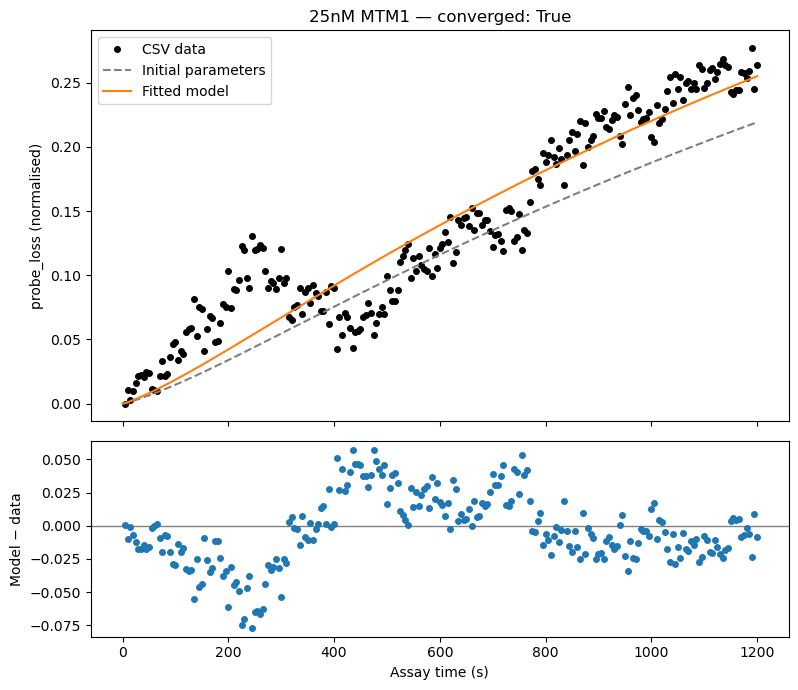

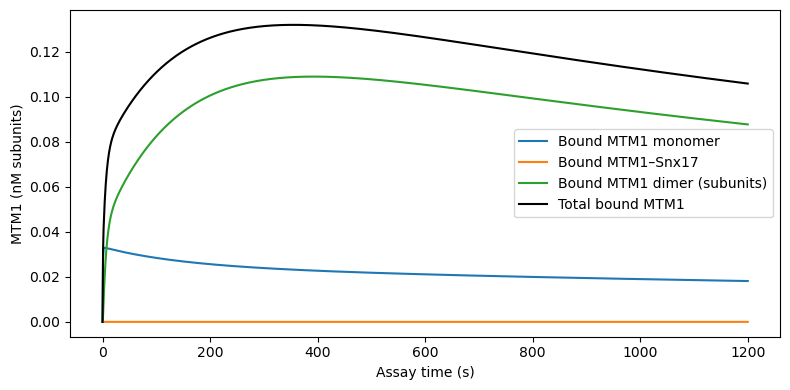

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1]})
if SIGMA_COLUMN:
    axes[0].errorbar(t_data, y_data, yerr=sigma, fmt="o", label="CSV data", color="black", markersize=4)
else:
    axes[0].plot(t_data, y_data, "o", label="CSV data", color="black", markersize=4)
initial_curve = simulate(settings_from_log(log_initial), plot_times)[0]
axes[0].plot(plot_times, initial_curve, "--", label="Initial parameters", color="grey")
axes[0].plot(plot_times, plot_signal, label="Fitted model", color="tab:orange")
axes[0].set_ylabel(OBSERVABLE + (" (nM)" if OBSERVABLE.endswith("_nM") else " (normalised)"))
axes[0].set_title(f"{SIGNAL_COLUMN} — converged: {result.success}")
axes[0].legend()
axes[1].axhline(0, color="grey", linewidth=1)
axes[1].plot(t_data, fit_prediction - y_data, "o", markersize=4)
axes[1].set(xlabel="Assay time (s)", ylabel="Model − data")
fig.tight_layout()
plt.show()

states = sol_fit.sol(plot_times)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(plot_times, states[7], label="Bound MTM1 monomer")
ax.plot(plot_times, states[10], label="Bound MTM1–Snx17")
ax.plot(plot_times, 2 * states[13], label="Bound MTM1 dimer (subunits)")
ax.plot(plot_times, states[7] + states[10] + 2 * states[13], label="Total bound MTM1", color="black")
ax.set(xlabel="Assay time (s)", ylabel="MTM1 (nM subunits)")
ax.legend()
fig.tight_layout()
plt.show()

## 9. Export results and a separate fitted YAML

In [9]:
# Re-running this cell replaces these fit outputs, not the original parameter YAML.
if not result.success:
    raise RuntimeError("Fit did not converge; review it before exporting final parameters.")
parameter_table.to_csv(str(OUTPUT_PREFIX) + "_parameters.csv", index=False)
comparison = pd.DataFrame({"time_s": t_data, "observed": y_data,
                           "initial_prediction": initial_prediction,
                           "fitted_prediction": fit_prediction,
                           "residual_model_minus_data": fit_prediction - y_data})
if SIGMA_COLUMN:
    comparison["sigma"] = sigma
comparison.to_csv(str(OUTPUT_PREFIX) + "_predictions.csv", index=False)
pd.DataFrame({"time_s": plot_times, OBSERVABLE: plot_signal}).to_csv(
    str(OUTPUT_PREFIX) + "_curve.csv", index=False)
with open(str(OUTPUT_PREFIX) + "_parameters.yaml", "w", encoding="utf-8") as f:
    yaml.safe_dump(fitted_config, f, sort_keys=False)
# Record the choices needed to interpret/reproduce this fit.
import json
with open(str(OUTPUT_PREFIX) + "_settings.json", "w", encoding="utf-8") as f:
    json.dump({"csv": str(CSV_PATH), "time_column": TIME_COLUMN,
               "time_to_seconds": TIME_TO_SECONDS, "signal_column": SIGNAL_COLUMN,
               "sigma_column": SIGMA_COLUMN, "observable": OBSERVABLE,
               "normalisation": NORMALISATION, "normalisation_step_s": NORMALISATION_STEP_S,
               "fit_parameters": FIT_PARAMETERS, "condition_overrides": CONDITION_OVERRIDES,
               "linked_catalysis": LINK_CATALYTIC_RATES, "solver": FIT_SOLVER,
               "converged": bool(result.success), "message": result.message,
               "SSE": float(np.sum((fit_prediction-y_data)**2)),
               "max_numerical_difference": max_numerical_difference}, f, indent=2)
print(f"Saved fit outputs with prefix: {OUTPUT_PREFIX.name}")

Saved fit outputs with prefix: fit_dimerisation
